# 5.2 Seguimiento de experimentos

Para la sexta semana de un proyecto usted habrá entrenado decenas de variantes de un modelo. Sin un registro, «la corrida buena» se vuelve un rumor: usted recuerda que la profundidad 8 funcionó, pero no con qué tasa de aprendizaje, sobre qué versión de los datos, ni si el 0.83 que recuerda era de validación o de prueba. El seguimiento de experimentos es la disciplina de anotar cuatro cosas en cada corrida, de forma automática:

1. **Parámetros** — cada perilla: hiperparámetros, opciones de datos, semilla.
2. **Métricas** — qué midió, sobre qué partición.
3. **Artefactos** — qué produjo la corrida: archivo del modelo, figuras, predicciones.
4. **Versión del código** — el *commit* de Git, para que la corrida quede atada al código exacto.

La disciplina importa más, no menos, cuando es un agente el que corre los experimentos por usted. Un agente que reporta «la profundidad 8 fue la mejor» está haciendo una afirmación; los registros de las corridas son la manera de comprobarla. En este cuaderno construimos un rastreador completo en unas 30 líneas de Python, lo usamos en un miniestudio real, y luego vemos qué agregan las herramientas industriales (MLflow, Weights & Biases) sobre las mismas ideas. Sin dependencias nuevas.

🖥️ [**Diapositivas — Sesión 27 (vie 4 dic)**](https://geo-smart.github.io/mlgeo-book/slides/2026/lec27_ship_it_honestly.html)

## Un rastreador mínimo

Una corrida = un archivo JSON en `./runs/`. Ese es todo el diseño. JSON porque es legible por humanos y admite comparación de diferencias; un archivo por corrida porque así las corridas nunca se sobrescriben entre sí.

In [1]:
import json
import subprocess
import time
import uuid
from pathlib import Path

import pandas as pd

RUNS_DIR = Path("runs")


def git_rev():
    """Current commit hash, or 'unknown' outside a git repo."""
    try:
        out = subprocess.run(["git", "rev-parse", "--short", "HEAD"],
                             capture_output=True, text=True, check=True)
        return out.stdout.strip()
    except Exception:
        return "unknown"


def log_run(params, metrics, artifacts=None, runs_dir=RUNS_DIR):
    """Record one experiment: params + metrics + artifacts + code version."""
    runs_dir.mkdir(exist_ok=True)
    record = {
        "run_id": uuid.uuid4().hex[:8],
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "code_version": git_rev(),
        "params": params,
        "metrics": metrics,
        "artifacts": artifacts or [],
    }
    path = runs_dir / f"run_{record['run_id']}.json"
    path.write_text(json.dumps(record, indent=2))
    return record["run_id"]


def load_runs(runs_dir=RUNS_DIR):
    """All runs as one flat DataFrame (params and metrics as columns)."""
    rows = []
    for path in sorted(runs_dir.glob("run_*.json")):
        r = json.loads(path.read_text())
        rows.append({"run_id": r["run_id"], "code_version": r["code_version"],
                     **r["params"], **r["metrics"]})
    return pd.DataFrame(rows)

Ese es el rastreador completo. `log_run` se llama una vez al final de cada corrida de entrenamiento; `load_runs` convierte el directorio en una tabla para analizarla. Todo lo demás en este cuaderno consiste en *usarlo*.

```{note}
Borramos `./runs/` al inicio del estudio para que el cuaderno sea idempotente — reejecutarlo no mezcla corridas viejas con nuevas. En un proyecto real usted conservaría el directorio y dejaría que creciera; *es* su cuaderno de laboratorio.
```

## Un miniestudio real: clasificación de litología

El estudio: clasificar la litología a partir de la tabla sintética de geoquímica del capítulo 2 (`mlgeo_synth.geochem_table`, con 5 % de ruido en las etiquetas para no hacer trampa), usando el `HistGradientBoostingClassifier` de scikit-learn. Barremos una malla pequeña — tres tasas de aprendizaje por dos profundidades de árbol, seis corridas — y hacemos seguimiento de cada corrida.

In [2]:
import numpy as np
import shutil
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

from mlgeo_synth import geochem_table

# Idempotent notebook: start the study from an empty runs directory.
if RUNS_DIR.exists():
    shutil.rmtree(RUNS_DIR)

df = geochem_table(n=6000, label_noise=0.05, seed=11)
feature_cols = [c for c in df.columns if c != "label"]
X, y = df[feature_cols], df["label"]

# Train / validation / test. The test split exists but stays untouched:
# every decision in this notebook is made on the validation split.
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=0)

print(f"train {len(X_train)}, val {len(X_val)}, test {len(X_test)} (untouched)")

train 3600, val 1200, test 1200 (untouched)


In [3]:
def run_experiment(learning_rate, max_depth, seed=0):
    """Train one model, log one run, return its run_id."""
    params = {
        "model": "HistGradientBoostingClassifier",
        "learning_rate": learning_rate,
        "max_depth": max_depth,
        "seed": seed,
        "data": "geochem_table(n=6000, label_noise=0.05, seed=11)",
    }
    t0 = time.time()
    clf = HistGradientBoostingClassifier(
        learning_rate=learning_rate, max_depth=max_depth, random_state=seed)
    clf.fit(X_train, y_train)
    metrics = {
        "train_f1_macro": f1_score(y_train, clf.predict(X_train), average="macro"),
        "val_f1_macro": f1_score(y_val, clf.predict(X_val), average="macro"),
        "fit_seconds": round(time.time() - t0, 2),
    }
    return log_run(params, metrics)


for lr in [0.03, 0.1, 0.5]:
    for depth in [2, 8]:
        run_id = run_experiment(learning_rate=lr, max_depth=depth)
        print(f"logged run {run_id}: lr={lr}, depth={depth}")

logged run 59a87189: lr=0.03, depth=2


logged run 2ea65d76: lr=0.03, depth=8


logged run 5839a691: lr=0.1, depth=2


logged run d4f8712c: lr=0.1, depth=8


logged run 827befe3: lr=0.5, depth=2


logged run 737fb4ac: lr=0.5, depth=8


## Cargar, comparar, decidir

Ahora hay seis archivos JSON en `./runs/`. La recompensa: comparar es una operación sobre un DataFrame, no arqueología.

In [4]:
runs = load_runs()
runs[["run_id", "learning_rate", "max_depth",
      "train_f1_macro", "val_f1_macro", "fit_seconds"]].round(3)

,run_id,learning_rate,max_depth,train_f1_macro,val_f1_macro,fit_seconds
0,2ea65d76,0.03,8,0.959,0.951,6.59
1,5839a691,0.10,2,0.946,0.952,0.73
2,59a87189,0.03,2,0.945,0.952,0.74
3,737fb4ac,0.50,8,1.000,0.953,4.04
4,827befe3,0.50,2,0.995,0.936,0.75
5,d4f8712c,0.10,8,1.000,0.951,6.07


In [5]:
table = runs.pivot_table(index="learning_rate", columns="max_depth",
                         values="val_f1_macro").round(3)
print("validation macro-F1:")
table

validation macro-F1:


max_depth,2,8
learning_rate,,
0.03,0.952,0.951
0.10,0.952,0.951
0.50,0.936,0.953


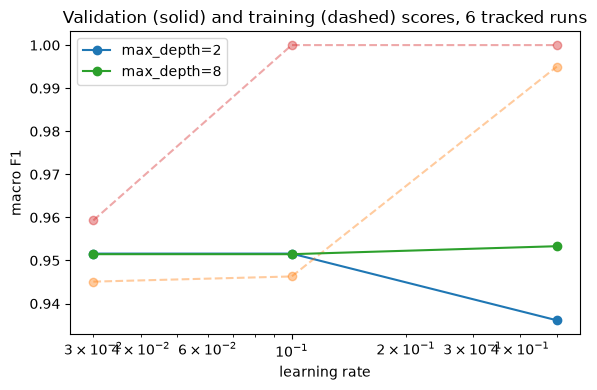

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
for depth, group in runs.groupby("max_depth"):
    g = group.sort_values("learning_rate")
    ax.plot(g["learning_rate"], g["val_f1_macro"], "o-", label=f"max_depth={depth}")
    ax.plot(g["learning_rate"], g["train_f1_macro"], "o--", alpha=0.4)
ax.set_xscale("log")
ax.set_xlabel("learning rate")
ax.set_ylabel("macro F1")
ax.set_title("Validation (solid) and training (dashed) scores, 6 tracked runs")
ax.legend()
fig.tight_layout()

In [7]:
best = runs.loc[runs["val_f1_macro"].idxmax()]
print(f"winner on the VALIDATION split: run {best['run_id']} "
      f"(lr={best['learning_rate']}, depth={best['max_depth']}, "
      f"val F1={best['val_f1_macro']:.3f})")

winner on the VALIDATION split: run 737fb4ac (lr=0.5, depth=8, val F1=0.953)


Lea la gráfica antes de seguir. Las curvas punteadas de entrenamiento trepan hacia 1.0 a medida que crecen la tasa de aprendizaje y la profundidad, mientras que las curvas sólidas de validación se mantienen planas cerca de 0.95 — los modelos profundos y agresivos están memorizando el 5 % de ruido en las etiquetas, y eso no les compra nada en validación. Con etiquetas ruidosas, un F1 de entrenamiento de 1.000 es una advertencia, no un logro. La única configuración que claramente *pierde* es la más agresiva entre las someras (tasa de aprendizaje 0.5, profundidad 2), que subajusta la estructura de las clases mientras reacciona en exceso al ruido.

Note también qué pequeños son los márgenes: las cuatro mejores configuraciones caen dentro de unas pocas milésimas entre sí, y la «ganadora» aventaja por unos 0.002. Guarde esa idea para el ejercicio.

Dos reglas que seguimos, ambas del hilo de evaluación justa de los capítulos 3 y 4:

- **La ganadora se elige sobre la partición de validación.** La partición de prueba no se ha tocado. Si ahora reportáramos el puntaje de *validación* de la ganadora como resultado principal, estaría sesgado de forma optimista — elegimos el máximo de seis números ruidosos. La partición de prueba se gasta exactamente una vez, al final del proyecto.
- **Cada número de la tabla se rastrea hasta un archivo de corrida** con sus parámetros, su versión del código y su marca de tiempo. Cuando alguien del equipo (o un agente, o la persona que revisa) pregunte «¿cómo saben cuál corrida fue la mejor?», la respuesta es un archivo, no un recuerdo.

## Qué agregan MLflow y Weights & Biases

Nuestro rastreador de 30 líneas registra parámetros, métricas, artefactos y versión del código. Ese es también, exactamente, el modelo de datos de las herramientas industriales — [MLflow](https://mlflow.org/) (código abierto, autoalojado o gestionado) y [Weights & Biases](https://wandb.ai/) (servicio alojado, con nivel académico gratuito). Lo que agregan es ingeniería alrededor de los mismos cuatro registros:

- **Una interfaz.** Tablas de corridas ordenables, gráficas de coordenadas paralelas, curvas de pérdida que se actualizan en vivo durante el entrenamiento — nuestro `load_runs()` y matplotlib, pero instantáneos y compartibles.
- **Almacenes de artefactos.** Nosotros registramos *rutas* a los artefactos; ellas almacenan los artefactos mismos (pesos de modelos, figuras, conjuntos de datos) con control de versiones y deduplicación, de modo que «el modelo de la corrida 7f3a» se puede descargar años después.
- **Colaboración.** Un equipo comparte un servidor de seguimiento; las corridas de cada integrante aterrizan en el mismo lugar buscable, con control de acceso. Esta es la diferencia que importa a escala de laboratorio.
- **Integraciones.** Retrollamadas de registro automático para scikit-learn, PyTorch y afines registran parámetros y métricas sin llamadas explícitas a `log_run`, más orquestación de barridos de hiperparámetros.

Los conceptos son idénticos, y ese es el punto de haber construido usted mismo el rastreador: cuando adopte MLflow para su proyecto final (algo que fomentamos), sabrá con precisión qué está haciendo y qué le habría dado gratis un directorio `runs/` de archivos JSON. Use las herramientas de verdad cuando trabaje con otras personas; nunca las confunda con la disciplina misma.

## Ejercicio: varianza entre corridas

Su estudio con seguimiento tiene una debilidad: todas las corridas usaron `seed=0`. Así que «la profundidad 8 le gana a la profundidad 2 por 0.01» podría ser un hecho, o podría ser suerte de la inicialización y del submuestreo.

**Tarea.** Usando `run_experiment`, agregue corridas con seguimiento para la configuración ganadora con al menos tres semillas distintas. Cargue todas las corridas y cuantifique la varianza entre corridas: media, desviación estándar y rango de `val_f1_macro` entre semillas. Luego responda: ¿cuáles diferencias de su tabla de seis corridas son mayores que la dispersión entre semillas — y por lo tanto reales?

````{admonition} Solución
:class: dropdown

```python
# three more tracked runs, winning config, different seeds
for seed in [1, 2, 3]:
    run_experiment(learning_rate=best["learning_rate"],
                   max_depth=best["max_depth"], seed=seed)

runs = load_runs()
mask = ((runs["learning_rate"] == best["learning_rate"])
        & (runs["max_depth"] == best["max_depth"]))
spread = runs.loc[mask, "val_f1_macro"]
print(f"n={len(spread)}, mean={spread.mean():.4f}, "
      f"std={spread.std():.4f}, range={spread.max() - spread.min():.4f}")
```

Resultado típico con estos datos: una desviación estándar entre semillas de unas pocas milésimas en el F1 macro de validación. Ahora relea la tabla dinámica con esa regla en la mano. Las cuatro mejores configuraciones difieren en aproximadamente esas mismas pocas milésimas — incluido el margen de 0.002 de la «ganadora». Esas diferencias no son hallazgos; a partir de corridas únicas usted no puede afirmar que alguna sea la mejor, y el informe honesto dice «indistinguibles al nivel de nuestra varianza entre corridas; elegimos la más somera y barata». La única brecha que *sí* mide muchas desviaciones estándar es la caída a 0.936 con tasa de aprendizaje 0.5 y profundidad 2 — esa configuración de verdad es peor.

El hábito general: cada vez que compare dos configuraciones, conozca primero su dispersión entre semillas. Una diferencia menor que la dispersión no es un hallazgo. Esta es la ablación más barata que correrá jamás, y el rastreador la redujo a tres líneas.
````